# Preprocessing and Exploratory Analysis


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

## Preprocessing

BSAC data downloaded from (Supplemental_Data_S1.csv): https://genome.cshlp.org/content/suppl/2017/06/29/gr.216606.116.DC1


In [2]:
# load NORM data

norm_data = pd.read_excel("data/mmc2.xlsx", engine = 'openpyxl') # this is the NORM data


# load BSAC data
bsac_data = pd.read_csv("data/Supplemental_Data_S1.csv")


df = norm_data


# load babybiome data
or_data = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")

In [3]:
print("NORM Data:")
print("Total number of observations:", norm_data.shape[0])
print("ST131 observations:", norm_data.loc[norm_data['ST'] == 131].shape[0])

NORM Data:
Total number of observations: 3254
ST131 observations: 272


In [4]:
# take a look
print(df.shape)
print(df.columns)
df.head()

(3254, 63)
Index(['lane', 'Run accession', 'popPUNK_cluster', 'ST', 'CC131_clades',
       'Duplicate', 'year', 'Lab', 'Hospital name',
       'Regional health authority', 'Clermont_Phylotype', 'FimH', 'folP',
       'gyrA', 'parC', 'gyrA_parC', 'parE', 'pmrB', 'blaTEM1', 'strB', 'sul2',
       'strA', 'sul1', 'dfrA', 'tetA', 'tetB', 'aadA', 'mphA', 'dfrA1',
       'aac3_Iia', 'catA1', 'dfrA5', 'CTX-M-type', 'CTX-M', 'dfrA14', 'blaOXA',
       'aph3', 'catB3', 'acc', 'blaSHV', 'dfrA12', 'sul3', 'cmlA1', 'dfrA8',
       'C_mefB', 'QnrS1', 'floR', 'Ampicillin_SIR', 'Aztreonam_SIR',
       'Cefotaxim_SIR', 'Ceftazidim_SIR', 'Cefuroxim_SIR', 'Ciprofloxacin_SIR',
       'Ciprofloxacin_NS', 'ESBL', 'Gentamicin_SIR', 'Meropenem_SIR',
       'Nalidixin_SIR', 'Piperacillin_tazobactam_SIR', 'Sulfa_SIR',
       'Tigecyklin_SIR', 'Tobramycin_SIR', 'Trimetoprim_sulfa_SIR'],
      dtype='object')


,lane,Run accession,popPUNK_cluster,ST,CC131_clades,Duplicate,year,Lab,Hospital name,Regional health authority,...,Ciprofloxacin_NS,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Sulfa_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR
0,30134_6#100,ERR4034085,1,73,NaN,NaN,2004,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,NaN,NaN,S
1,30134_6#101,ERR4034086,8,127,NaN,NaN,2015,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,I,NaN,S,NaN,S
2,30134_6#103,ERR4034087,3,69,NaN,NaN,2013,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,S,NaN,R
3,30134_6#104,ERR4034088,1,73,NaN,NaN,2005,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,NaN,NaN,S
4,30134_6#105,ERR4034089,5,537,NaN,NaN,2011,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,S,NaN,S


In [5]:
# describe
df.describe(include=['object']) # use 'object' for categorical data

,lane,Run accession,CC131_clades,Duplicate,Lab,Hospital name,Regional health authority,Clermont_Phylotype,FimH,folP,...,Ciprofloxacin_SIR,Ciprofloxacin_NS,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR
count,3254,3254,278,3,3254,3254,3254,3254,3254,2,...,3253,3254,2075,3254,3085,798,3254,2501,196,3254
unique,3254,3254,6,2,15,15,4,11,263,1,...,3,2,4,3,3,2,3,4,3,3
top,30134_6#100,ERR4034085,A,Duplicated in plate,Haukeland,Haukeland universitetssykehus,Helse Sør-Øst,B2,fimH27,folP.P64S,...,S,S,-,S,S,S,S,S,S,S
freq,1,1,75,2,399,399,1625,2180,521,2,...,2876,2876,1263,2992,3081,705,3109,2480,188,2401


## Visualization

Figure 1: Barplot of the counts of STs (10 most common)

Figure 2: Barplot of the counts of STs over time


How cool would that be to:
- Create an interactive network visualization of the counts of specific STs etc in specific hospitals! And then you could cycle through the years.


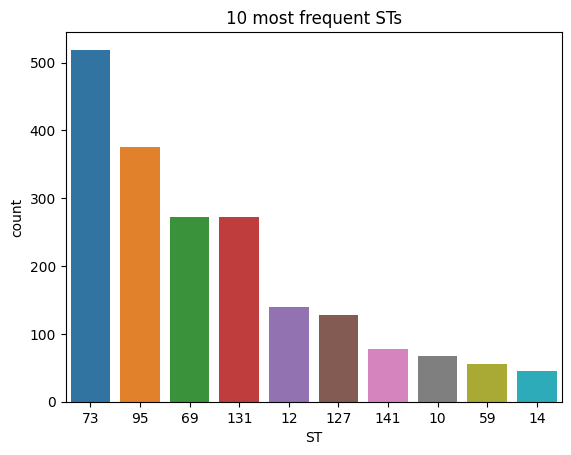

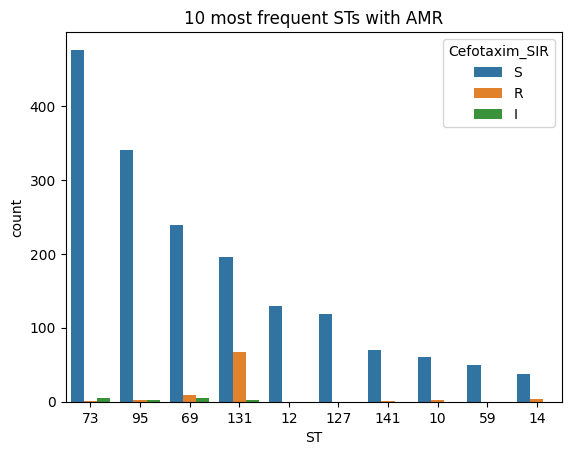

In [6]:
feat = "ST"
N = 10

# ten most frequent STs
sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index)
plt.title(str(N) + " most frequent " + feat + "s")
plt.show()

amr = 'Cefotaxim_SIR'
sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index, hue = amr)
plt.title(str(N) + " most frequent " + feat + "s with AMR")
plt.show()

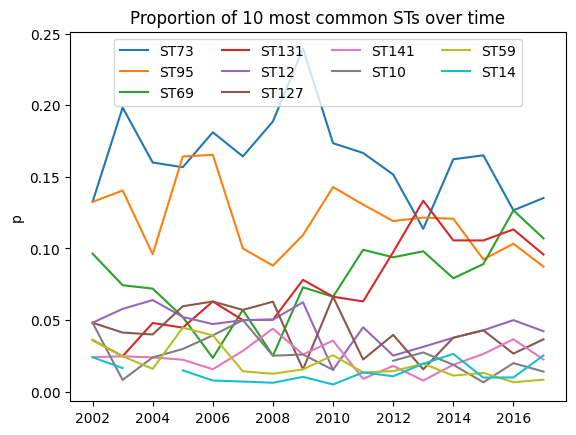

In [7]:
# plot the ten most common STs over time
st = 131
df_vis = pd.value_counts(df.loc[df['ST'] == st]["year"])/pd.value_counts(df["year"])
for st in pd.value_counts(df["ST"]).iloc[:N].index:
    df_vis = pd.value_counts(df.loc[df['ST'] == st]["year"]).sort_index()/pd.value_counts(df["year"]).sort_index()
    plt.plot(df_vis.index, df_vis, label = "ST" + str(st))
plt.legend(loc="upper center", ncol = 4)
plt.ylabel("p")
plt.title("Proportion of " + str(N) + " most common STs over time")
plt.show()

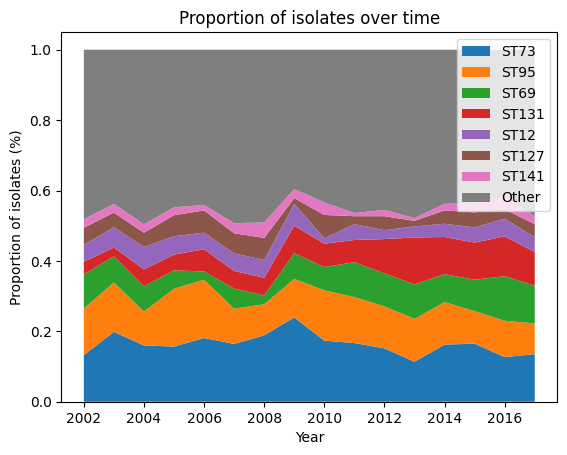

In [8]:
# the stackplot recreation
y = []
x = pd.value_counts(df["year"]).sort_index().index
N = 7
for st in pd.value_counts(df["ST"]).iloc[:N].index:
    y.append(list(pd.value_counts(df.loc[df['ST'] == st]["year"]).sort_index()/pd.value_counts(df["year"]).sort_index()))

# todo: add an aggregate column that has all the other STs stacked to one line
other_sts = list(pd.value_counts(df["ST"]).iloc[N:len(np.unique(df["ST"]))].index) # the other STs
y_other = list(pd.value_counts(df.loc[df['ST'].isin(other_sts)]["year"])/pd.value_counts(df["year"]).sort_index())
# labels
labs = ["ST" + str(i) for i in list(pd.value_counts(df["ST"]).iloc[:N].index)]
labs.append("Other")

# combine
y.append(y_other)

plt.stackplot(x,y,labels=labs)
plt.legend(loc='upper right')
plt.title("Proportion of isolates over time")
plt.ylabel("Proportion of isolates (%)")
plt.xlabel("Year")
plt.show()


[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
             p     t
2002  0.036145  2002
2003  0.024793  2003
2004  0.048000  2004
2005  0.044776  2005
2006  0.062992  2006
(16, 2)
RangeIndex(start=0, stop=3254, step=1)
Index(['p', 't'], dtype='object')


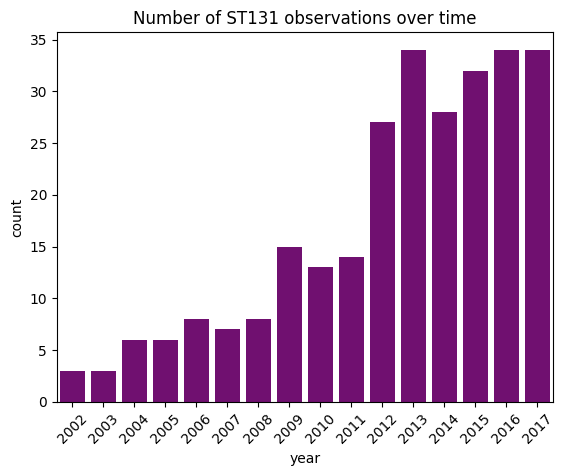

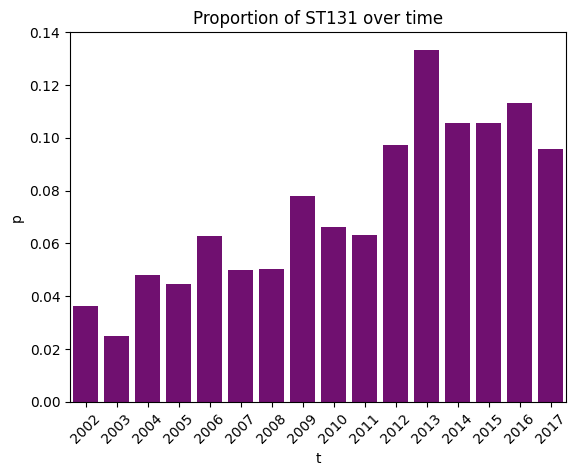

In [9]:
# TODO

df.head(5)


st = 131

# plot the proportion of ST31 over each year. Barplot with CIs. Or boxplot?

# step 1: calculate the prop of the st of interest for one year
year = 2004

df_vis = pd.DataFrame(pd.value_counts(df.loc[df['ST'] == st]["year"])/pd.value_counts(df["year"])).rename(columns = {"year": "p"}) # same as the line plot


years = [row for row in df_vis.index]
df_vis["t"] = years
print(years)

print(df_vis.head(5))
print(df_vis.shape)
print(df.index)
print(df_vis.columns)

# one vs all: number of observations
sns.countplot(data = df.loc[df['ST'] == st], x = "year", color = "purple")
plt.title("Number of ST" + str(st) + " observations over time")
plt.xticks(rotation = 45)
plt.show()

# one vs all: proportion of observations
sns.barplot(data = df_vis, x = "t", y = "p", color = "purple")
plt.title("Proportion of ST" + str(st) + " over time")
plt.xticks(rotation = 45)
plt.show()


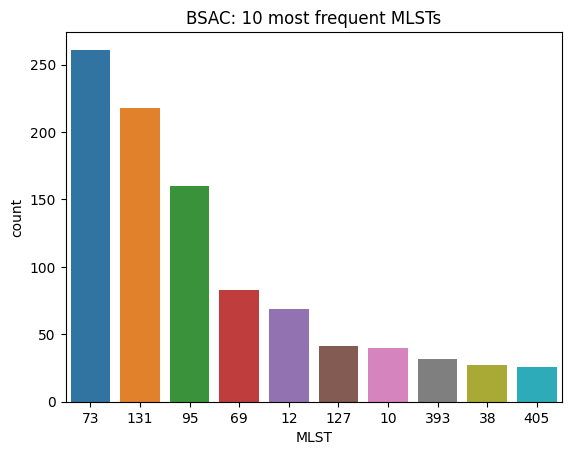

In [10]:
# BSAC data barplot:
## ST counts
def get_n_most_freq(df, N, feat = "ST", data_id = "Data"):
    # Get N most frequent categorical feature values
    
    sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index)
    plt.title(data_id + ": " + str(N) + " most frequent " + feat + "s")
    plt.show()
    
get_n_most_freq(bsac_data, N = 10, feat = "MLST", data_id = "BSAC")

#get_n_most_freq(norm_data, N = 10, feat = "ST", data_id = "NORM")

## Resistance related figures

In [15]:
df["ESBL"]

0       -         
1                -
2       -         
3       -         
4       -         
           ...    
3249    -         
3250    -         
3251           NaN
3252    -         
3253    -         
Name: ESBL, Length: 3254, dtype: object

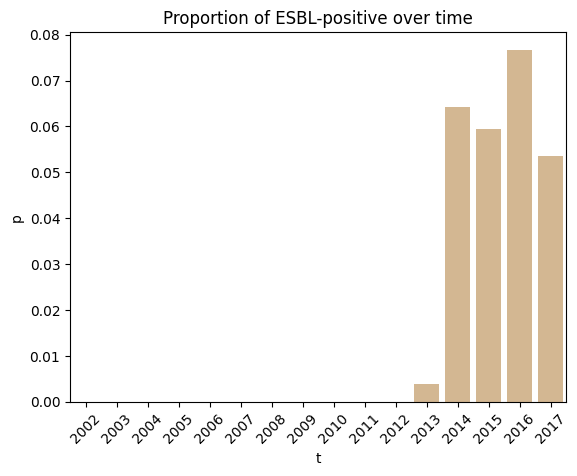

In [17]:
# ESBL over time

esbl_vis = pd.DataFrame(pd.value_counts(df.loc[df['ESBL'] == '+']["year"])/pd.value_counts(df["year"])).rename(columns = {"year": "p"}) # same as the line plot
years = [row for row in esbl_vis.index]
esbl_vis["t"] = years

sns.barplot(data = esbl_vis, x = "t", y = "p", color = "burlywood")
plt.title("Proportion of ESBL-positive over time")
plt.xticks(rotation = 45)
plt.show()

In [20]:
df.columns

Index(['lane', 'Run accession', 'popPUNK_cluster', 'ST', 'CC131_clades',
       'Duplicate', 'year', 'Lab', 'Hospital name',
       'Regional health authority', 'Clermont_Phylotype', 'FimH', 'folP',
       'gyrA', 'parC', 'gyrA_parC', 'parE', 'pmrB', 'blaTEM1', 'strB', 'sul2',
       'strA', 'sul1', 'dfrA', 'tetA', 'tetB', 'aadA', 'mphA', 'dfrA1',
       'aac3_Iia', 'catA1', 'dfrA5', 'CTX-M-type', 'CTX-M', 'dfrA14', 'blaOXA',
       'aph3', 'catB3', 'acc', 'blaSHV', 'dfrA12', 'sul3', 'cmlA1', 'dfrA8',
       'C_mefB', 'QnrS1', 'floR', 'Ampicillin_SIR', 'Aztreonam_SIR',
       'Cefotaxim_SIR', 'Ceftazidim_SIR', 'Cefuroxim_SIR', 'Ciprofloxacin_SIR',
       'Ciprofloxacin_NS', 'ESBL', 'Gentamicin_SIR', 'Meropenem_SIR',
       'Nalidixin_SIR', 'Piperacillin_tazobactam_SIR', 'Sulfa_SIR',
       'Tigecyklin_SIR', 'Tobramycin_SIR', 'Trimetoprim_sulfa_SIR'],
      dtype='object')

In [34]:
df["Sulfa_SIR"].unique()

array([nan])

/tmp/ipykernel_14647/1051445007.py:17: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if res not in df[antibiotic].unique():


No R cases for Sulfa_SIR


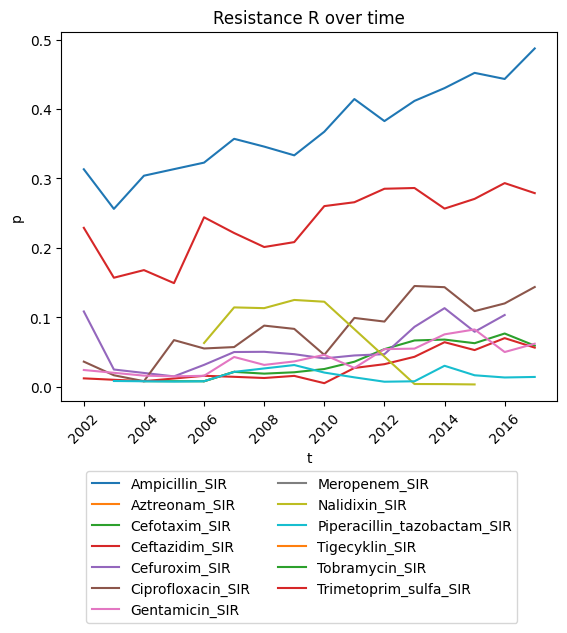

In [50]:
# SIR (sus - intermediate - res) over time


def plot_resistance(antibiotic, res, color = "burlywood"):
    # Plot a barplot of the proportion of resistant isolates by year
    res_vis = pd.DataFrame(pd.value_counts(df.loc[df[antibiotic] == res]["year"])/pd.value_counts(df["year"])).rename(columns = {"year": "p"}) # same as the line plot
    years = [row for row in esbl_vis.index]
    res_vis["t"] = years

    try:
        sns.lineplot(data = res_vis, x = "t", y = "p", label = antibiotic)
        #plt.plot(res_vis, x = "t", y = "p")
        plt.legend(loc=(0.05, -0.6), ncol = 2)
        plt.title(f'Resistance ({res}) over time')
        plt.xticks(rotation = 45)
    except KeyError:
        if res not in df[antibiotic].unique():
            print(f'No {res} cases for {antibiotic}')
        else:
            print(f'Unknown key error, {antibiotic}')
    #plt.show()
    
    
antibiotics = ['Ampicillin_SIR', 'Aztreonam_SIR', 'Cefotaxim_SIR',\
               'Ceftazidim_SIR', 'Cefuroxim_SIR', 'Ciprofloxacin_SIR',\
              'Gentamicin_SIR', 'Meropenem_SIR', 'Nalidixin_SIR',\
               'Piperacillin_tazobactam_SIR', 'Sulfa_SIR',\
               'Tigecyklin_SIR', 'Tobramycin_SIR', 'Trimetoprim_sulfa_SIR']


antibiotic = "Ampicillin_SIR"
res = "R"

#plot_resistance(antibiotic, res)
for a in antibiotics:
    plot_resistance(a, "R")

plt.show()
    
# better alternative: line plot, one line per antibiotic. Could put everything in the same figure



## Functions

In [ ]:
def get_obs_BSI_ST(df, ST, as_prop = True):
    
    if as_prop:
        theta_BSI_obs_ST = pd.value_counts(df.loc[df['ST'] == ST]["year"])/pd.value_counts(df["year"]) # STX out of all STs in the data per year.
    else:
         theta_BSI_obs_ST = pd.value_counts(df.loc[df['ST'] == ST]["year"])
    
    return theta_BSI_obs_ST


def get_obs_BSI_ST131(df, clade, as_prop = True):
    # Get the proportion of clade out of all ST131 observations per year
    
    df = df.loc[df['ST'] == 131] # clades known for ST131
    
    cladecol = 'CC131_clades'
    if 'clade' in df.columns:
        cladecol = 'clade'
        
    if as_prop:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"])/pd.value_counts(df["year"])# n clades per year/n all ST131 obs
    else:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"]) # these are counts directly
    
    return theta_BSI_obs
